# Netflix Data Analysis
This notebook analyzes a Netflix dataset containing over 8,000 titles. We'll explore the types of content, release trends, countries of production, and ratings using pandas, Matplotlib, and Seaborn.


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Enable inline plotting
%matplotlib inline

In [14]:
df = pd.read_csv('C:/Users/preci/Downloads/archive (1)/dataset.csv')
df = pd.read_csv('C:/Users/preci/Downloads/archive (1)/dataset.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [15]:
df.shape
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8804,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,15-Aug,Rajiv Chilaka,David Attenborough,United States,1-Jan-20,NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,2,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [16]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [17]:
# Drop rows where 'type' or 'title' is missing (critical info)
df.dropna(subset=['type', 'title'], inplace=True)

# Fill remaining missing values with 'Unknown'
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna('Unknown', inplace=True)
df['date_added'].fillna('Unknown', inplace=True)


In [18]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        3
listed_in       0
description     0
dtype: int64

In [19]:
df.drop(columns=['show_id'], inplace=True)

In [21]:
df['date_added'] = pd.to_datetime(df['date_added'], format='%B %d, %Y', errors='coerce')

In [22]:
df['year_added'] = df['date_added'].dt.year

In [23]:
print(df[['date_added', 'year_added']].head())

  date_added  year_added
0 2021-09-25      2021.0
1 2021-09-24      2021.0
2 2021-09-24      2021.0
3 2021-09-24      2021.0
4 2021-09-24      2021.0


In [24]:
print(df['type'].value_counts())

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [25]:
print(df['country'].value_counts().head(10))

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


In [26]:
print(df['release_year'].value_counts().sort_index())

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64


In [27]:
print(df['rating'].value_counts())

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
Unknown        4
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


In [28]:
# Some entries have multiple genres separated by commas — we'll split and count them
from collections import Counter

genre_counts = Counter()
df['listed_in'].apply(lambda x: genre_counts.update(x.split(', ')))
print(genre_counts.most_common(10))

[('International Movies', 2752), ('Dramas', 2427), ('Comedies', 1674), ('International TV Shows', 1351), ('Documentaries', 869), ('Action & Adventure', 859), ('TV Dramas', 763), ('Independent Movies', 756), ('Children & Family Movies', 641), ('Romantic Movies', 616)]


In [29]:
print(df['director'].value_counts().head(10))

director
Unknown                   2634
Rajiv Chilaka               19
Raúl Campos, Jan Suter      18
Suhas Kadav                 16
Marcus Raboy                16
Jay Karas                   14
Cathy Garcia-Molina         13
Jay Chapman                 12
Youssef Chahine             12
Martin Scorsese             12
Name: count, dtype: int64


In [30]:
content_by_year = df.groupby(['release_year', 'type']).size().unstack()
print(content_by_year.tail(10))  # last 10 years

type          Movie  TV Show
release_year                
2012          173.0     64.0
2013          225.0     63.0
2014          264.0     88.0
2015          398.0    162.0
2016          658.0    244.0
2017          767.0    265.0
2018          767.0    380.0
2019          633.0    397.0
2020          517.0    436.0
2021          277.0    315.0


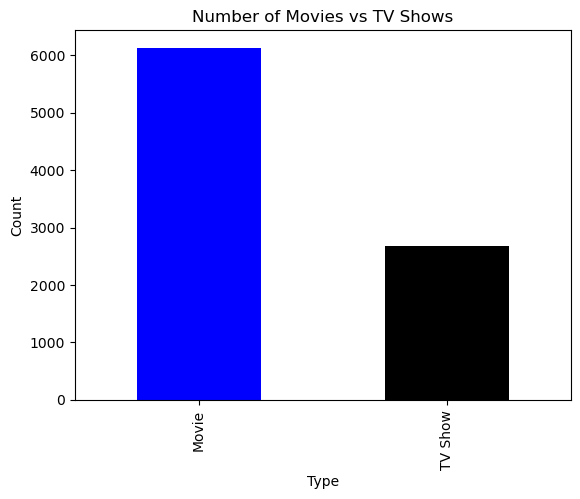

In [43]:
import matplotlib.pyplot as plt

df['type'].value_counts().plot(kind='bar', color=['blue', 'black'])
plt.title('Number of Movies vs TV Shows')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()


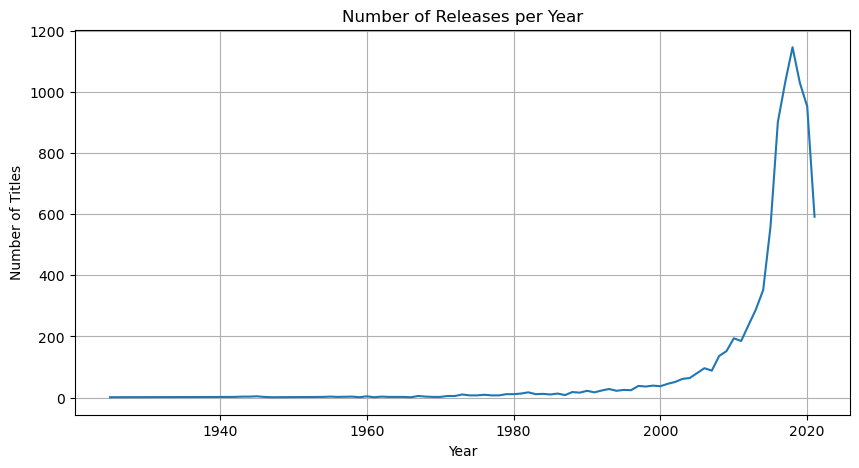

In [44]:
df.groupby('release_year').size().plot(kind='line', figsize=(10,5))
plt.title('Number of Releases per Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.grid(True)
plt.show()

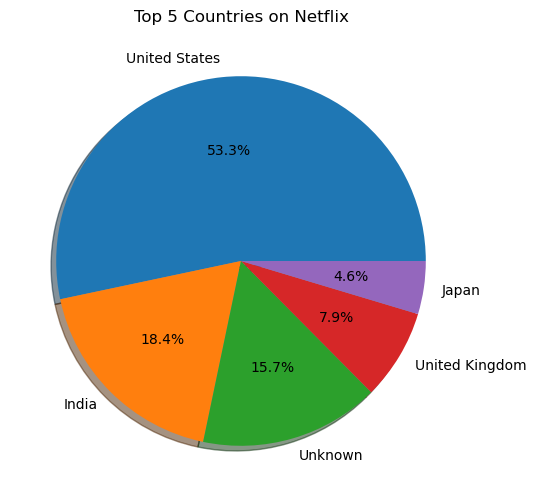

In [45]:
top_countries = df['country'].value_counts().head(5)
top_countries.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6), shadow=True)
plt.title('Top 5 Countries on Netflix')
plt.ylabel('')
plt.show()

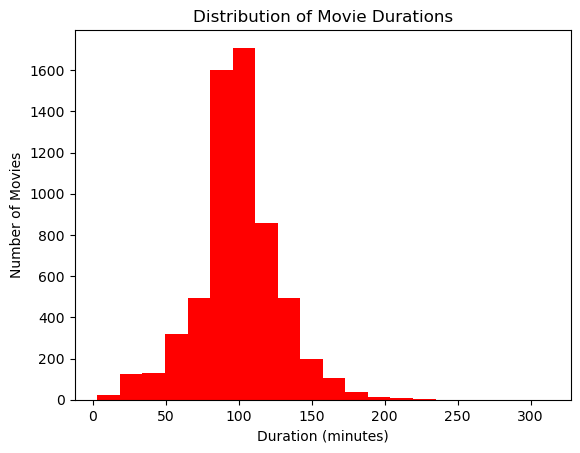

In [50]:
movie_df = df[df['type'] == 'Movie'].copy()
movie_df['duration_minutes'] = movie_df['duration'].str.extract('(\d+)').astype(float)

plt.hist(movie_df['duration_minutes'].dropna(), bins=20, color='red')
plt.title('Distribution of Movie Durations')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.show()

In [33]:
# Filter only movies from the dataset
movie_df = df[df['type'] == 'Movie'].copy()

# Extract numeric duration in minutes
movie_df['duration_minutes'] = movie_df['duration'].str.extract('(\d+)').astype(float)

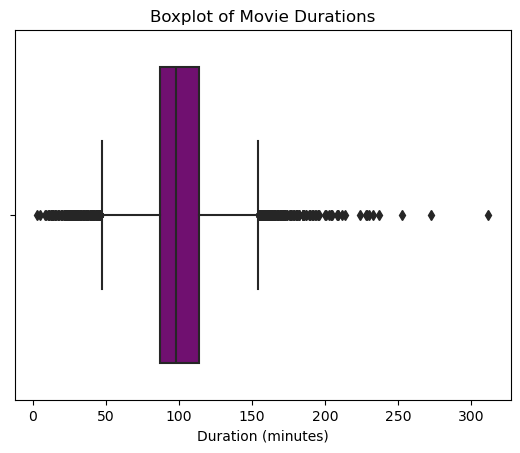

In [38]:
sns.boxplot(x=movie_df['duration_minutes'], color='purple')
plt.title('Boxplot of Movie Durations')
plt.xlabel('Duration (minutes)')
plt.show()

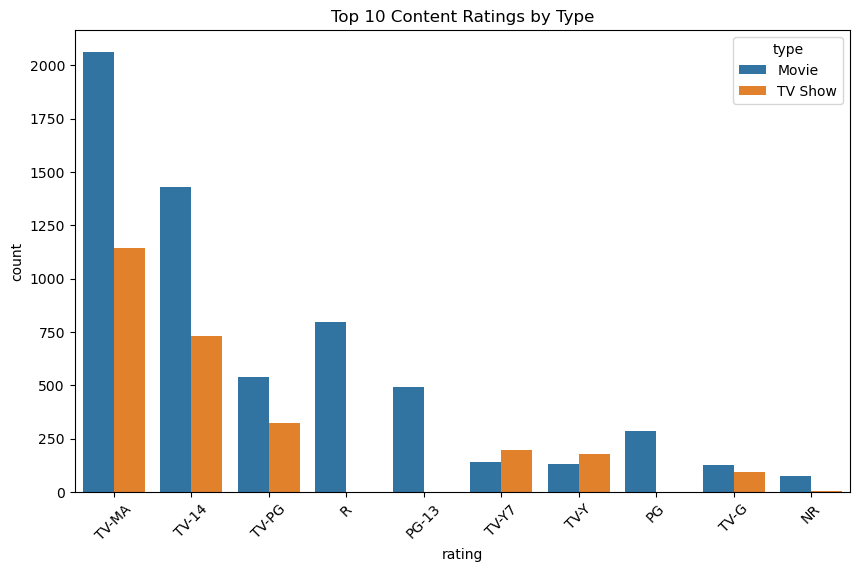

In [39]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='rating', hue='type', order=df['rating'].value_counts().index[:10])
plt.title('Top 10 Content Ratings by Type')
plt.xticks(rotation=45)
plt.show()

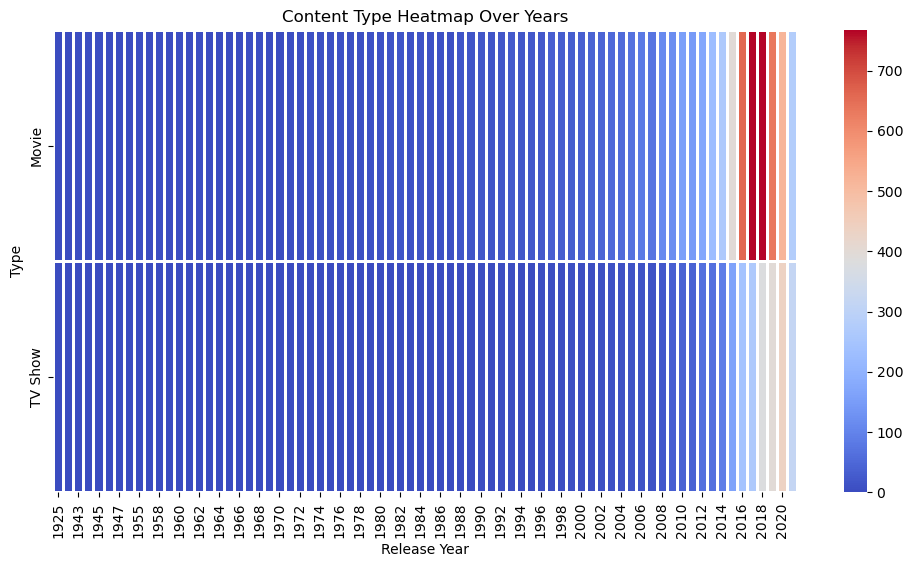

In [40]:
plt.figure(figsize=(12,6))
heat_df = df.groupby(['release_year', 'type']).size().unstack().fillna(0)
sns.heatmap(heat_df.T, cmap='coolwarm', linecolor='white', linewidths=1)
plt.title('Content Type Heatmap Over Years')
plt.xlabel('Release Year')
plt.ylabel('Type')
plt.show()

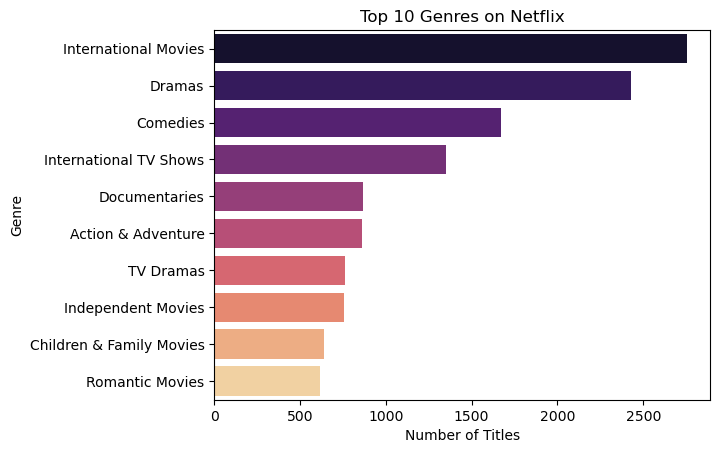

In [41]:
top_genres = pd.DataFrame(genre_counts.most_common(10), columns=['Genre', 'Count'])

sns.barplot(data=top_genres, x='Count', y='Genre', palette='magma')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.show()